# 1장 — Inference Performance 기본기

이 커리큘럼은 decoder-only Transformer의 **추론**을 빠르게 만드는 법을 다룹니다.
1장의 목표는 최적화 기법을 배우는 게 아니라, **무엇을 최적화해야 하는지 판별하는 눈**을 갖는 것입니다.

최적화 기법은 대부분 둘 중 하나를 겨냥합니다. 연산을 줄이거나, 메모리 이동을 줄이거나.
어느 쪽이 병목인지 모르고 손대면 아무 일도 일어나지 않습니다.
그래서 1장은 전부 **측정과 분류**에 관한 것입니다.

### 이 장에서 다루는 것

| 절 | 주제 |
|---|---|
| §1 | 측정의 규율 — 잘못 재면 나머지가 전부 무의미해진다 |
| §2 | Latency vs Throughput |
| §3 | TTFT vs TPOT |
| §4 | Prefill vs Decode |
| §5 | FLOPs · 메모리 대역폭 · Arithmetic Intensity |
| §6 | Compute-bound vs Memory-bound |
| §7 | Roofline model |
| §8 | batch size · sequence length · hidden dimension의 영향 |
| §9 | 정리와 연습문제 |

### 1장에서 가져가야 할 단 하나의 직관

같은 Transformer, 같은 가중치인데도 추론의 두 단계는 완전히 다른 기계를 돌립니다.

$$\textbf{Prefill} \approx \text{GEMM 중심} \qquad\longrightarrow\qquad \text{연산량이 병목 (compute-bound)}$$

$$\textbf{Decode} \approx \text{GEMV / memory access 중심} \qquad\longrightarrow\qquad \text{메모리 대역폭이 병목 (memory-bound)}$$

프롬프트 $T$개 토큰을 한 번에 넣는 prefill은 행렬 × 행렬입니다. 가중치를 한 번 읽어 $T$개 토큰에 재사용하죠.
반면 decode는 한 번에 토큰 하나입니다. 같은 가중치 전체를 읽어서 벡터 하나에만 씁니다.
**읽는 양은 같은데 쓰는 양이 $T$배 적습니다.** 이 한 문장이 추론 최적화의 거의 모든 것을 설명합니다.

이 노트북은 그 주장을 글로 하지 않고, 이 GPU에서 직접 재서 보여줍니다.

## §0. 준비 — 이 숫자들이 어느 기계에서 나왔는지

성능 수치는 하드웨어를 떼면 의미가 없습니다. 먼저 우리가 어떤 기계 위에 있는지 기록해 둡니다.

In [1]:
import time

import matplotlib.pyplot as plt
import torch

from infer_opt import profiling as prof
from infer_opt.config import ModelConfig, RunConfig
from infer_opt.runner import prepare, synchronize

torch.manual_seed(0)

# 실험 대상 모델: 실제 서빙 모델의 축소판 (GQA 16:4, SwiGLU, RoPE, 246M params)
CFG = ModelConfig(
    vocab_size=32000,
    hidden_size=1024,
    n_layers=16,
    n_heads=16,
    n_kv_heads=4,
    intermediate_size=2816,
    max_seq_len=2048,
)
RUN = RunConfig(batch_size=1, prompt_len=1024, decode_len=64, device="auto", dtype="float16")

model, DEVICE, DTYPE, PROMPT, CONTINUATION = prepare(CFG, RUN)
INFO = prof.device_summary(DEVICE)

for key, value in INFO.items():
    print(f"{key:>20} : {value}")
print(f"{'params':>20} : {prof.parameter_count(CFG) / 1e6:.0f}M")
print(f"{'weight bytes':>20} : {prof.parameter_bytes(CFG, DTYPE) / 1e6:.0f} MB ({RUN.dtype})")

              device : cuda
               torch : 2.14.0+cu130
          cuda_build : 13.0
                name : NVIDIA GeForce RTX 2080 SUPER
  compute_capability : 7.5
            sm_count : 48
     total_memory_gb : 8.589606912
      bf16_supported : True
              params : 246M
        weight bytes : 492 MB (float16)


**dtype 주의.** 이 노트북은 `float16`을 씁니다. `torch.cuda.is_bf16_supported()`가 `True`를 돌려줘도
그것이 곧 "빠르다"는 뜻은 아닙니다 — bf16 텐서코어는 compute capability 8.0(Ampere) 이상이고,
그 아래에서는 에뮬레이션으로 돌아 오히려 느려집니다. 위 출력의 `compute_capability`를 보고 판단하세요.
추론에서 dtype은 정확도 선택이자 **대역폭 선택**입니다. fp32 → fp16은 읽어야 할 가중치 바이트를 절반으로 줄입니다.

## §1. 측정의 규율

최적화 이야기를 시작하기 전에 측정부터 바로잡아야 합니다.
GPU 벤치마크는 **틀리기가 맞기보다 훨씬 쉽습니다.** 두 가지 함정을 직접 봅시다.

### 함정 1 — CUDA는 비동기다

`c = a @ b`는 GPU에 "이 일을 해라"라고 **주문만 넣고 즉시 반환**합니다.
그래서 `perf_counter`로 그 줄을 감싸면 계산 시간이 아니라 **주문을 넣는 시간**이 찍힙니다.

고치는 방법은 두 가지입니다.
- `torch.cuda.synchronize()`로 측정 구간 끝에서 GPU가 끝나기를 기다린다.
- 더 낫게는 **CUDA event**를 커널과 같은 스트림에 기록한다. 이러면 호스트 시계가 아니라 디바이스 시계로 잽니다.

`profiling.timeit()`이 그 두 번째 방식이고, 이 노트북의 모든 시간은 여기서 나옵니다.

In [2]:
a = torch.randn(4096, 4096, device=DEVICE, dtype=DTYPE)
b = torch.randn(4096, 4096, device=DEVICE, dtype=DTYPE)
matmul_flops = 2 * 4096**3

# cuBLAS 초기화/커널 로딩을 먼저 끝내 둔다. 이걸 빼먹으면 첫 호출에 그 비용이 섞여
# "동기화를 빼먹은 측정"이 오히려 느리게 나와 함정이 가려진다 (그 자체가 warmup의 필요성).
for _ in range(3):
    a @ b
synchronize(DEVICE)

# (1) 순진한 측정: 동기화 없음 -> 커널 실행이 아니라 "주문 넣기"를 잰다
started = time.perf_counter()
c = a @ b
naive_ms = 1000 * (time.perf_counter() - started)

# (2) 동기화한 측정: 정직하다. 단, 한 번만 재면 그날의 운에 좌우된다
synchronize(DEVICE)
started = time.perf_counter()
c = a @ b
synchronize(DEVICE)
synced_ms = 1000 * (time.perf_counter() - started)

# (3) warmup + CUDA event + 중앙값
timing = prof.timeit(lambda: a @ b, device=DEVICE, warmup=5, iters=20)

print(f"{'no sync (launch only)':<28} {naive_ms:8.3f} ms   -> {matmul_flops / (naive_ms / 1e3) / 1e12:8.1f} TFLOP/s (거짓)")
print(f"{'sync, single shot':<28} {synced_ms:8.3f} ms   -> {matmul_flops / (synced_ms / 1e3) / 1e12:8.1f} TFLOP/s")
print(f"{'warmup + CUDA events':<28} {timing.ms:8.3f} ms   -> {timing.tflops(matmul_flops):8.1f} TFLOP/s  (std {timing.ms_std:.3f})")
del a, b, c
torch.cuda.empty_cache() if DEVICE.type == "cuda" else None

no sync (launch only)           0.392 ms   ->    350.6 TFLOP/s (거짓)
sync, single shot               6.346 ms   ->     21.7 TFLOP/s
warmup + CUDA events            3.999 ms   ->     34.4 TFLOP/s  (std 0.361)


첫 줄은 이 GPU의 물리적 한계를 아득히 넘는 TFLOP/s를 보고합니다. 물리 법칙을 어긴 게 아니라 **측정이 거짓말**을 한 겁니다.
벤치마크 결과가 하드웨어 스펙을 넘으면 거의 항상 동기화를 빠뜨린 것입니다.

참고로 위 셀은 측정 전에 일부러 몇 번 워밍업을 돌립니다. 그걸 빼면 첫 호출에 cuBLAS 초기화 비용이 섞여
동기화를 빼먹은 측정이 오히려 *느리게* 나오고, 함정이 우연히 가려집니다.
**warmup과 동기화는 둘 다 있어야 합니다.**

### 함정 2 — 호스트가 GPU를 못 먹일 때

두 번째 함정은 더 미묘합니다. decode 한 스텝은 연산량이 아주 적은 대신 **커널 수가 매우 많습니다**
(레이어마다 projection·RoPE·norm·attention…). 커널 하나를 GPU에 제출하는 데 드는 CPU 비용이
커널이 실제로 도는 시간보다 크면, GPU는 일감을 기다리며 놀게 됩니다. 이걸 **launch-bound(호스트 바운드)** 라고 합니다.

이 상태에서 잰 시간은 "이 GPU가 느리다"가 아니라 "이 Python이 느리다"입니다. 구분해서 봐야 합니다.
아래에서 같은 decode 스텝을 세 가지로 재 봅니다.

In [3]:
@torch.inference_mode()
def cache_filled_to(batch: int, context_len: int):
    # context_len - 1개 위치가 이미 채워진 KV 캐시와, 다음에 넣을 토큰 하나를 만든다.
    cache = model.new_cache(batch, DEVICE, DTYPE)
    model.forward_prefill(PROMPT[:, : context_len - 1].repeat(batch, 1), cache)
    return cache, CONTINUATION[:, :1].repeat(batch, 1)


def release() -> None:
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()


CONTEXT = 513
with torch.inference_mode():
    cache, next_token = cache_filled_to(batch=1, context_len=CONTEXT)
    anchor = cache.position

    def decode_step() -> None:
        cache.position = anchor          # 재실행을 위해 위치를 되돌린다
        model.forward_decode(next_token, cache)

    for _ in range(10):
        decode_step()
    synchronize(DEVICE)

    # (1) 정직한 wall-clock: CUDA event
    eager = prof.timeit(decode_step, device=DEVICE, warmup=5, iters=30)

    # (2) 호스트가 커널을 제출하는 데만 쓴 시간 (동기화 없이 루프를 돈 뒤 마지막에 한 번만 sync)
    synchronize(DEVICE)
    started = time.perf_counter()
    for _ in range(30):
        decode_step()
    launch_ms = 1000 * (time.perf_counter() - started) / 30
    synchronize(DEVICE)

    # (3) CUDA graph: 스텝 전체를 한 번에 제출 -> 런치 비용이 사라진 '진짜 디바이스 시간'
    replay = prof.capture_graph(decode_step, device=DEVICE)

    def graph_step() -> None:
        cache.position = anchor
        replay()

    graphed = prof.timeit(graph_step, device=DEVICE, warmup=5, iters=30)

print(f"{'eager decode (wall)':<28} {eager.ms:7.2f} ms/step -> {1000 / eager.ms:7.1f} tok/s")
print(f"{'  ...host launch cost only':<28} {launch_ms:7.2f} ms/step")
print(f"{'CUDA graph replay (device)':<28} {graphed.ms:7.2f} ms/step -> {1000 / graphed.ms:7.1f} tok/s")
print(f"\n커널 제출에만 {launch_ms:.1f} ms — 스텝 전체({eager.ms:.1f} ms)와 사실상 같다.")
print(f"실제 디바이스 작업은 {graphed.ms:.1f} ms 뿐이므로, GPU는 그 스텝의 {1 - graphed.ms / eager.ms:.0%}를 놀고 있었다.")

eager decode (wall)            30.23 ms/step ->    33.1 tok/s
  ...host launch cost only     30.30 ms/step
CUDA graph replay (device)      5.40 ms/step ->   185.1 tok/s

커널 제출에만 30.3 ms — 스텝 전체(30.2 ms)와 사실상 같다.
실제 디바이스 작업은 5.4 ms 뿐이므로, GPU는 그 스텝의 82%를 놀고 있었다.


`launch cost only`가 `eager decode`와 거의 같다면, 그 스텝 동안 **GPU는 대부분 놀고 있었다**는 뜻입니다.
CUDA graph로 재생하면 같은 계산이 몇 배 빨라지는데, 커널을 더 빠르게 만든 게 아니라 **제출 비용만 없앤** 것입니다.

그래서 이 노트북은 decode를 잴 때 두 숫자를 같이 봅니다.

- **eager** — 이 호스트에서 순진하게 짰을 때 실제로 나오는 속도
- **graph** — 이 GPU가 낼 수 있는 속도, 즉 메모리/연산 병목만 남긴 값

§5부터의 roofline 분석은 하드웨어를 논하는 것이므로 **graph 쪽 숫자**를 씁니다.
(그리고 방금 본 것이 "실전에서 CUDA graph를 왜 쓰는가"에 대한 답이기도 합니다 — 뒤 장에서 다시 만납니다.)

In [4]:
@torch.inference_mode()
def time_decode(batch: int, context_len: int, *, use_graph: bool = True, iters: int = 30) -> prof.Timing:
    # decode 한 스텝의 시간. use_graph=False면 이 호스트에서 순진하게 잰 값.
    cache, next_token = cache_filled_to(batch, context_len)
    anchor = cache.position

    def step() -> None:
        cache.position = anchor
        model.forward_decode(next_token, cache)

    if use_graph:
        replay = prof.capture_graph(step, device=DEVICE)

        def step_to_time() -> None:
            cache.position = anchor
            replay()
    else:
        step_to_time = step

    timing = prof.timeit(step_to_time, device=DEVICE, warmup=5, iters=iters)
    del cache
    release()
    return timing


@torch.inference_mode()
def time_prefill(batch: int, length: int, *, use_graph: bool = True, iters: int = 10) -> prof.Timing:
    # 프롬프트 length개 토큰을 한 번에 넣는 prefill 한 번의 시간.
    cache = model.new_cache(batch, DEVICE, DTYPE)
    token_ids = PROMPT[:, :length].repeat(batch, 1)

    def step() -> None:
        cache.reset()
        model.forward_prefill(token_ids, cache)

    step_to_time = prof.capture_graph(step, device=DEVICE) if use_graph else step
    timing = prof.timeit(step_to_time, device=DEVICE, warmup=3, iters=iters)
    del cache
    release()
    return timing


print("측정 헬퍼 준비 완료")

측정 헬퍼 준비 완료


## §2. Latency vs Throughput

두 지표는 자주 같이 쓰이지만 **서로 다른 사람의 관심사**입니다.

- **Latency (지연)** — 요청 하나가 끝나기까지 걸리는 시간. *사용자*가 느끼는 값.
- **Throughput (처리량)** — 단위 시간당 처리한 토큰/요청 수. *GPU를 빌린 사람*이 지불하는 값.

핵심은 둘이 **하나를 올리면 하나가 내려가는 트레이드오프**라는 것입니다. 그 손잡이가 batch size입니다.
여러 요청의 decode 스텝을 한 번에 묶으면, 가중치를 한 번만 읽어 여러 시퀀스에 씁니다.
GPU 입장에서는 거의 공짜라 처리량은 배수로 늘지만, 각 요청은 남을 기다리므로 지연은 늘어납니다.

In [5]:
BATCHES = [1, 2, 4, 8, 16, 32]
rows = []
for batch in BATCHES:
    timing = time_decode(batch, CONTEXT, use_graph=True)
    rows.append(
        {
            "batch": batch,
            "ms": timing.ms,
            "tok_s": batch * 1000 / timing.ms,
            "ai": prof.step_workload(CFG, batch=batch, new_tokens=1, context_len=CONTEXT, dtype=DTYPE).arithmetic_intensity,
        }
    )

print(f"{'batch':>6} {'step latency':>14} {'throughput':>14} {'vs batch=1':>12}")
for row in rows:
    print(f"{row['batch']:>6} {row['ms']:>11.2f} ms {row['tok_s']:>10,.0f} tok/s {row['tok_s'] / rows[0]['tok_s']:>11.1f}x")

 batch   step latency     throughput   vs batch=1
     1        4.62 ms        216 tok/s         1.0x
     2        5.08 ms        393 tok/s         1.8x
     4        5.53 ms        723 tok/s         3.3x
     8        6.52 ms      1,227 tok/s         5.7x
    16        8.68 ms      1,843 tok/s         8.5x
    32       13.43 ms      2,383 tok/s        11.0x


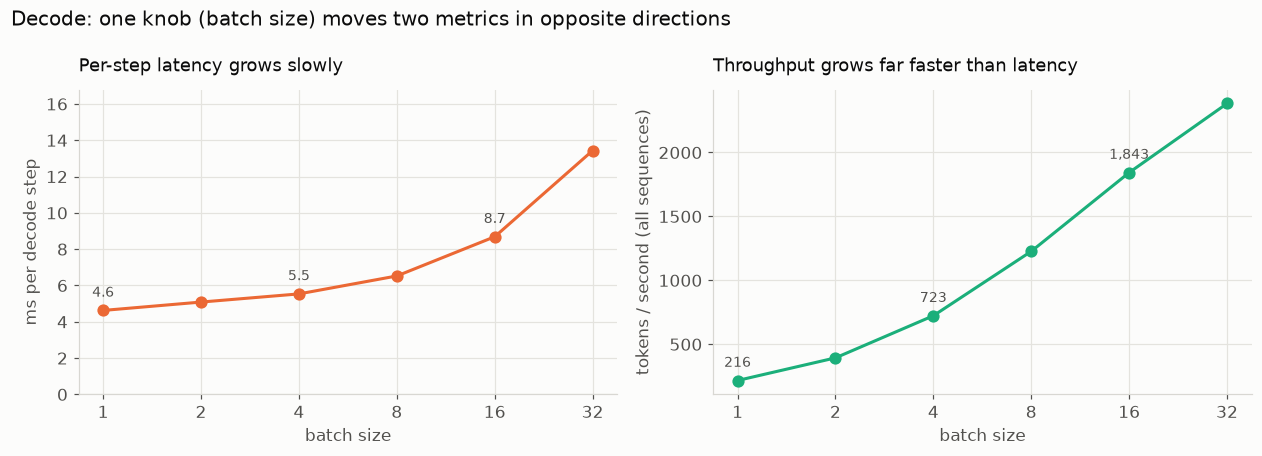

In [6]:
PREFILL_COLOR, DECODE_COLOR, ACCENT_COLOR = "#2a78d6", "#eb6834", "#1baf7a"
SURFACE, INK, INK_SOFT, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3de"

plt.rcParams.update(
    {
        "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
        "axes.edgecolor": "#d8d7d2", "axes.labelcolor": INK_SOFT, "text.color": INK,
        "xtick.color": INK_SOFT, "ytick.color": INK_SOFT, "grid.color": GRID,
        "axes.grid": True, "grid.linewidth": 0.8, "axes.axisbelow": True,
        "axes.spines.top": False, "axes.spines.right": False,
        "font.size": 11, "figure.dpi": 110, "lines.linewidth": 2, "lines.markersize": 7,
        "axes.titlesize": 12, "axes.titlelocation": "left", "axes.titlepad": 12,
    }
)

figure, (left, right) = plt.subplots(1, 2, figsize=(11.5, 4.2))

left.plot([r["batch"] for r in rows], [r["ms"] for r in rows], color=DECODE_COLOR, marker="o")
left.set_title("Per-step latency grows slowly")
left.set_xlabel("batch size"); left.set_ylabel("ms per decode step")
left.set_xscale("log", base=2); left.set_xticks(BATCHES); left.set_xticklabels(BATCHES)
left.set_ylim(0, max(r["ms"] for r in rows) * 1.25)
for row in rows[::2]:
    left.annotate(f"{row['ms']:.1f}", (row["batch"], row["ms"]), textcoords="offset points",
                  xytext=(0, 9), ha="center", color=INK_SOFT, fontsize=9)

right.plot([r["batch"] for r in rows], [r["tok_s"] for r in rows], color=ACCENT_COLOR, marker="o")
right.set_title("Throughput grows far faster than latency")
right.set_xlabel("batch size"); right.set_ylabel("tokens / second (all sequences)")
right.set_xscale("log", base=2); right.set_xticks(BATCHES); right.set_xticklabels(BATCHES)
for row in rows[::2]:
    right.annotate(f"{row['tok_s']:,.0f}", (row["batch"], row["tok_s"]), textcoords="offset points",
                   xytext=(0, 9), ha="center", color=INK_SOFT, fontsize=9)

figure.suptitle("Decode: one knob (batch size) moves two metrics in opposite directions", x=0.005, ha="left", fontsize=13)
figure.tight_layout()
plt.show()

지연은 조금 늘었는데 처리량은 거의 배수로 늘었습니다. **decode는 공짜 배칭 구간이 아주 넓습니다.**
이유는 §5에서 수식으로 나옵니다: batch를 키워도 **가중치를 읽는 바이트 수가 변하지 않기 때문**입니다.
GPU는 이미 메모리를 기다리며 놀고 있었으므로, 그 시간에 산술을 더 얹는 건 거의 공짜입니다.

실서비스에서는 이 곡선 위 어디에 설지를 **SLO**가 정합니다.
"p99 토큰당 50ms 이하"가 걸려 있으면 그 선을 넘지 않는 최대 batch가 답입니다.
지연 예산을 다 쓰지 않고 남기는 것은 곧 **돈을 남기는 것**입니다.

## §3. TTFT vs TPOT

사용자가 체감하는 지연은 하나의 숫자가 아닙니다. 스트리밍 응답은 두 국면으로 갈립니다.

- **TTFT (Time To First Token)** — 요청부터 첫 토큰까지. 곧 **prefill 시간**입니다. 프롬프트 길이에 좌우됩니다.
- **TPOT (Time Per Output Token)** — 그 뒤 토큰 하나당 시간. 곧 **decode 스텝 시간**입니다. 생성 길이에 좌우됩니다.

$$\text{End-to-end latency} \;=\; \text{TTFT} \;+\; \text{TPOT} \times (N_{\text{out}} - 1)$$

두 지표는 원인이 다르므로 처방도 다릅니다.
TTFT가 나쁘면 prefill(연산량, chunked prefill, 프롬프트 캐싱)을, TPOT이 나쁘면 decode(대역폭, 배칭, 양자화)를 봐야 합니다.
실제 생성 루프를 스텝별로 계측해 봅시다.

In [7]:
GENERATE = 16
PROMPT_LENS = [128, 256, 512, 1024]


def step_ms(fn) -> float:
    # 스텝 하나의 디바이스 시간. 스텝마다 이벤트를 찍어 파이프라인을 비운다.
    if DEVICE.type != "cuda":
        started = time.perf_counter()
        fn()
        return 1000 * (time.perf_counter() - started)
    start, end = torch.cuda.Event(True), torch.cuda.Event(True)
    start.record()
    fn()
    end.record()
    end.synchronize()
    return start.elapsed_time(end)


# (a) 순진하게 잰 실제 생성 루프 — 이 호스트에서 그대로 나오는 트레이스
eager_traces = {}
with torch.inference_mode():
    for prompt_len in (128, 1024):
        token_ids = PROMPT[:, :prompt_len]
        cache = model.new_cache(1, DEVICE, DTYPE)
        for _ in range(2):
            cache.reset()
            model.forward_prefill(token_ids, cache)
        synchronize(DEVICE)

        cache.reset()
        steps = [step_ms(lambda: model.forward_prefill(token_ids, cache))]
        for index in range(GENERATE - 1):
            token = CONTINUATION[:, index : index + 1]
            steps.append(step_ms(lambda: model.forward_decode(token, cache)))
        eager_traces[prompt_len] = steps
        del cache
        release()

# (b) 런치 비용을 걷어낸 디바이스 시간 — §1의 CUDA graph 기법
device_rows = []
for prompt_len in PROMPT_LENS:
    ttft = time_prefill(1, prompt_len, use_graph=True).ms
    tpot = time_decode(1, prompt_len + 1, use_graph=True).ms
    device_rows.append({"prompt": prompt_len, "ttft": ttft, "tpot": tpot})

print(f"{'prompt':>7} | {'TTFT eager':>11} {'TTFT device':>12} {'TPOT device':>12} | "
      f"{'E2E 16tok':>10} {'share':>7} | {'E2E 256tok':>11} {'share':>7}")
for row in device_rows:
    short = row["ttft"] + row["tpot"] * 15
    long = row["ttft"] + row["tpot"] * 255
    trace = eager_traces.get(row["prompt"])
    eager_ttft = f"{trace[0]:.1f} ms" if trace else "—"
    print(f"{row['prompt']:>7} | {eager_ttft:>11} {row['ttft']:>9.1f} ms {row['tpot']:>9.2f} ms | "
          f"{short:>7.0f} ms {row['ttft'] / short:>6.0%} | {long:>8.0f} ms {row['ttft'] / long:>6.0%}")

 prompt |  TTFT eager  TTFT device  TPOT device |  E2E 16tok   share |  E2E 256tok   share
    128 |     30.1 ms       5.7 ms      4.03 ms |      66 ms     9% |     1033 ms     1%
    256 |           —       7.5 ms      4.21 ms |      71 ms    11% |     1082 ms     1%
    512 |           —      12.6 ms      4.63 ms |      82 ms    15% |     1193 ms     1%
   1024 |     31.5 ms      25.3 ms      5.36 ms |     106 ms    24% |     1391 ms     2%


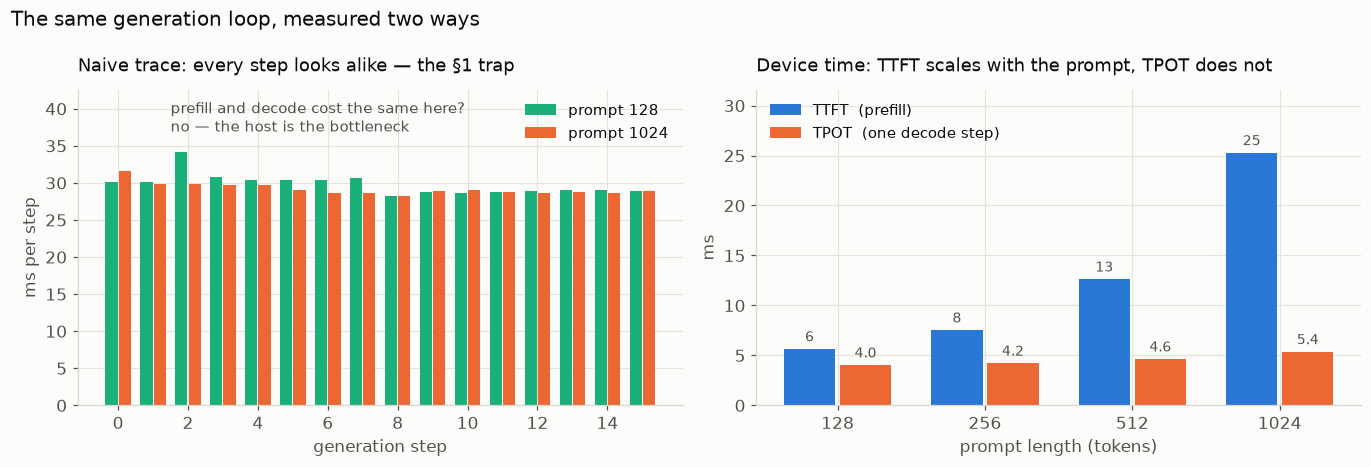

In [8]:
figure, (left, right) = plt.subplots(1, 2, figsize=(12.5, 4.3))

width = 0.38
for offset, (prompt_len, steps) in zip((-width / 2, width / 2), eager_traces.items()):
    color = ACCENT_COLOR if prompt_len == 128 else DECODE_COLOR
    left.bar([i + offset for i in range(len(steps))], steps, width=width * 0.92,
             color=color, label=f"prompt {prompt_len}")
left.set_title("Naive trace: every step looks alike — the §1 trap")
left.set_xlabel("generation step"); left.set_ylabel("ms per step")
left.set_xticks(range(0, GENERATE, 2))
left.set_ylim(0, max(eager_traces[1024]) * 1.35)
left.legend(frameon=False, loc="upper right", fontsize=10)
left.annotate("prefill and decode cost the same here?\nno — the host is the bottleneck",
              (1.5, max(eager_traces[128]) * 1.08), color=INK_SOFT, fontsize=10)

positions = range(len(device_rows))
right.bar([i - width / 2 for i in positions], [r["ttft"] for r in device_rows], width=width * 0.92,
          color=PREFILL_COLOR, label="TTFT  (prefill)")
right.bar([i + width / 2 for i in positions], [r["tpot"] for r in device_rows], width=width * 0.92,
          color=DECODE_COLOR, label="TPOT  (one decode step)")
right.set_title("Device time: TTFT scales with the prompt, TPOT does not")
right.set_xlabel("prompt length (tokens)"); right.set_ylabel("ms")
right.set_ylim(0, max(r["ttft"] for r in device_rows) * 1.25)
right.set_xticks(list(positions)); right.set_xticklabels([r["prompt"] for r in device_rows])
right.legend(frameon=False, loc="upper left", fontsize=10)
for index, row in enumerate(device_rows):
    right.annotate(f"{row['ttft']:.0f}", (index - width / 2, row["ttft"]), textcoords="offset points",
                   xytext=(0, 5), ha="center", color=INK_SOFT, fontsize=9)
    right.annotate(f"{row['tpot']:.1f}", (index + width / 2, row["tpot"]), textcoords="offset points",
                   xytext=(0, 5), ha="center", color=INK_SOFT, fontsize=9)

figure.suptitle("The same generation loop, measured two ways", x=0.005, ha="left", fontsize=13)
figure.tight_layout()
plt.show()

왼쪽 그래프는 함정입니다. 모든 막대의 높이가 같아서 "prefill과 decode의 비용이 같다"고 읽힙니다.
그럴 리가 없죠 — §1에서 봤듯 이 호스트에서는 두 단계 모두 **커널 제출 비용**에 묶여서, 재고 있는 것이 GPU가 아닙니다.

오른쪽이 진짜입니다. 런치 비용을 걷어내면 두 지표가 완전히 다르게 행동합니다.

- **TTFT는 프롬프트 길이를 따라 자랍니다.** 128 → 1024 토큰으로 8배 늘리면 TTFT도 대략 그만큼 늘어납니다.
  prefill이 하는 일이 토큰 수에 비례하기 때문입니다.
- **TPOT은 거의 평평합니다.** 프롬프트가 아무리 길어도 decode는 토큰을 하나만 처리합니다.
  (KV를 더 읽는 만큼 아주 조금은 자랍니다 — §8에서 따로 봅니다.)

위 표의 `share` 열이 실전 판단 근거입니다. 16토큰만 생성하는 요청에서는 TTFT가 지연의 큰 몫을 차지하지만,
256토큰을 생성하면 $\text{TPOT} \times 255$가 전체를 지배합니다.
**같은 모델, 같은 GPU라도 워크로드에 따라 최적화할 단계가 달라집니다.**
짧은 응답(분류·추출)이면 prefill을, 긴 응답(생성·에이전트)이면 decode를 파야 합니다.

그래서 서빙 시스템은 이 둘을 **별도의 SLO로 관리**합니다. 평균 지연 하나로 뭉치면
"프롬프트가 긴 요청이 첫 토큰을 3초 만에 뱉는" 문제가 평균 뒤에 숨습니다.

## §4. Prefill vs Decode — 왜 같은 모델이 두 개의 기계인가

이제 1장의 핵심 주장으로 갑니다. 두 단계의 차이는 **행렬 곱의 모양**에서 출발합니다.

같은 `q_proj` 가중치 $W \in \mathbb{R}^{h \times h}$를 쓰는데,

- **prefill**: 입력이 $X \in \mathbb{R}^{T \times h}$ → $XW$는 **GEMM** (행렬 × 행렬). $W$를 한 번 읽어 $T$개 토큰에 재사용.
- **decode**: 입력이 $x \in \mathbb{R}^{1 \times h}$ → $xW$는 **GEMV** (벡터 × 행렬). $W$를 똑같이 다 읽어 토큰 하나에만 사용.

attention도 마찬가지입니다. query 텐서의 모양이 `[B, H, T, D]`에서 `[B, H, 1, D]`로 바뀝니다.
`T` 축이 1로 접히는 순간, 재사용할 것이 사라집니다.

In [9]:
with torch.inference_mode():
    cache = model.new_cache(1, DEVICE, DTYPE)
    hidden = model.embedding(PROMPT[:, :512])
    attention = model.layers[0].attention
    query = attention.q_proj(hidden).view(1, 512, CFG.n_heads, CFG.head_dim).transpose(1, 2)
    print(f"prefill  hidden {tuple(hidden.shape)}  ->  query {tuple(query.shape)}   (GEMM: T={query.shape[2]})")

    hidden_one = model.embedding(CONTINUATION[:, :1])
    query_one = attention.q_proj(hidden_one).view(1, 1, CFG.n_heads, CFG.head_dim).transpose(1, 2)
    print(f"decode   hidden {tuple(hidden_one.shape)}    ->  query {tuple(query_one.shape)}     (GEMV: T={query_one.shape[2]})")
    del cache, hidden, query, hidden_one, query_one
release()

# 두 단계를 같은 방식으로 잰다: 디바이스 시간(graph)과, 이 호스트의 순진한 시간(eager)
prefill_timing = time_prefill(batch=1, length=512, use_graph=True)
prefill_eager = time_prefill(batch=1, length=512, use_graph=False)
decode_graph = time_decode(1, CONTEXT, use_graph=True)
decode_eager = time_decode(1, CONTEXT, use_graph=False)

prefill_tok_s = 512 * 1000 / prefill_timing.ms
decode_tok_s = 1000 / decode_graph.ms
print(f"\n{'phase':<24} {'device (graph)':>18} {'tokens/s':>10} | {'naive (eager)':>15}")
print(f"{'prefill (512 tokens)':<24} {prefill_timing.ms:>15.2f} ms {prefill_tok_s:>10,.0f} | {prefill_eager.ms:>12.2f} ms")
print(f"{'decode  (1 token)':<24} {decode_graph.ms:>15.2f} ms {decode_tok_s:>10,.0f} | {decode_eager.ms:>12.2f} ms")
print(f"\n토큰당 처리 속도 차이: {prefill_tok_s / decode_tok_s:,.0f}배 (같은 GPU, 같은 가중치)")

prefill  hidden (1, 512, 1024)  ->  query (1, 16, 512, 64)   (GEMM: T=512)
decode   hidden (1, 1, 1024)    ->  query (1, 16, 1, 64)     (GEMV: T=1)



phase                        device (graph)   tokens/s |   naive (eager)
prefill (512 tokens)               12.58 ms     40,715 |        67.21 ms
decode  (1 token)                   4.60 ms        217 |        28.99 ms

토큰당 처리 속도 차이: 187배 (같은 GPU, 같은 가중치)


같은 모델, 같은 GPU인데 **토큰당 처리 속도가 백 배 단위로 차이**납니다.
(`naive (eager)` 열도 같이 보세요. 순진하게 재면 두 단계가 비슷해 보여서 이 차이 자체가 안 보입니다.)

여기서 흔한 오해 하나를 짚고 갑니다. decode가 느린 건 "일이 많아서"가 아닙니다. **일이 너무 적어서**입니다.
토큰 하나를 위해 246M개 가중치를 전부 읽어와야 하는데, 읽어온 걸로 하는 계산은 겨우 곱셈 두 번씩입니다.
GPU의 연산기는 대부분 메모리를 기다리며 놉니다.

이 직관을 숫자로 확인하려면 시간이 아니라 **FLOPs와 바이트**를 세야 합니다. 다음 절입니다.

## §5. FLOPs · 메모리 · Arithmetic Intensity

두 개의 양을 셉니다.

- **FLOPs** — 해야 하는 부동소수점 연산 수. 행렬 곱 $[M \times K] \times [K \times N]$은 $2MKN$ FLOPs (곱셈+덧셈을 2로).
- **Bytes** — 메모리에서 옮겨야 하는 바이트 수. 가중치 + KV 캐시 + 활성값.

그리고 둘의 비율이 이 장에서 가장 중요한 한 개의 수입니다.

$$\text{Arithmetic Intensity (AI)} \;=\; \frac{\text{FLOPs}}{\text{Bytes}} \quad [\text{FLOP/byte}]$$

AI는 "메모리에서 1바이트 끌어올 때마다 연산을 몇 번 하는가"입니다.
**하드웨어와 무관한, 알고리즘 자체의 성질**이라는 점이 중요합니다. AI가 낮으면 어떤 GPU를 사도 메모리가 병목입니다.

In [10]:
def report(label: str, *, batch: int, new_tokens: int, context_len: int) -> None:
    flops = prof.transformer_flops(CFG, batch=batch, new_tokens=new_tokens, context_len=context_len)
    moved = prof.transformer_bytes(CFG, batch=batch, new_tokens=new_tokens, context_len=context_len, dtype=DTYPE)
    print(f"\n{label}")
    print(f"  FLOPs  {flops['total'] / 1e9:10.2f} GFLOP   "
          f"(linear {flops['linear'] / flops['total']:.0%}, attention {flops['attention'] / flops['total']:.0%}, lm_head {flops['lm_head'] / flops['total']:.0%})")
    print(f"  Bytes  {moved['total'] / 1e6:10.2f} MB      "
          f"(weights {moved['weights'] / moved['total']:.0%}, kv {(moved['kv_read'] + moved['kv_write']) / moved['total']:.0%}, activations {moved['activations'] / moved['total']:.0%})")
    print(f"  AI     {flops['total'] / moved['total']:10.2f} FLOP/byte")


report("PREFILL  512 tokens, batch 1", batch=1, new_tokens=512, context_len=512)
report("DECODE   1 token @ ctx 512, batch 1", batch=1, new_tokens=1, context_len=CONTEXT)
report("DECODE   1 token @ ctx 512, batch 32", batch=32, new_tokens=1, context_len=CONTEXT)


PREFILL  512 tokens, batch 1
  FLOPs      226.84 GFLOP   (linear 81%, attention 4%, lm_head 15%)
  Bytes     1044.71 MB      (weights 47%, kv 2%, activations 51%)
  AI         217.14 FLOP/byte

DECODE   1 token @ ctx 512, batch 1
  FLOPs        0.46 GFLOP   (linear 78%, attention 7%, lm_head 14%)
  Bytes      501.32 MB      (weights 98%, kv 2%, activations 0%)
  AI           0.92 FLOP/byte

DECODE   1 token @ ctx 512, batch 32
  FLOPs       14.72 GFLOP   (linear 78%, attention 7%, lm_head 14%)
  Bytes      794.84 MB      (weights 62%, kv 34%, activations 4%)
  AI          18.51 FLOP/byte


세 숫자에서 읽어야 할 것:

**1) decode의 바이트는 거의 전부 가중치입니다.** 토큰 하나를 뽑으려고 모델 전체를 메모리에서 끌어옵니다.
이것이 decode의 하한을 정합니다.

$$\text{TPOT} \;\geq\; \frac{\text{모델 가중치 바이트}}{\text{메모리 대역폭}}$$

이 하한은 GPU를 아무리 잘 써도 못 내려갑니다. 내리려면 **바이트를 줄여야** 합니다 — 그래서 양자화(fp16→int8→int4)가
decode 최적화의 정석입니다. 연산을 줄이는 게 아니라 읽을 양을 줄이는 것입니다.

**2) batch를 키워도 가중치 바이트는 그대로입니다.** FLOPs만 batch에 비례해 늘죠. 그래서

$$\text{AI}_{\text{decode}} \;\approx\; \frac{2 P \cdot B}{P \cdot s} \;=\; \frac{2B}{s} \;\xrightarrow{\;\text{fp16}, s=2\;}\; B$$

($P$ = 파라미터 수, $B$ = batch, $s$ = 원소당 바이트.)
**decode의 arithmetic intensity는 대략 batch size와 같습니다.** §2에서 배칭이 거의 공짜였던 이유가 이것입니다.

**3) prefill의 바이트는 절반이 활성값입니다.** 레이어마다 norm·projection·RoPE·SwiGLU의 중간 텐서를
HBM에 썼다가 다시 읽기 때문입니다. 이 트래픽은 *알고리즘이 요구하는 것이 아니라 구현이 만들어낸 것*이라,
커널 융합(FlashAttention이 대표적)이 겨냥하는 바로 그 항입니다. 융합하면 AI가 오른쪽으로 움직입니다.

**4) "토큰당 $2P$ FLOPs" 규칙.** 파라미터 하나당 곱셈 한 번과 덧셈 한 번이므로, 토큰 하나를 처리하는 데
대략 $2P$ FLOPs가 듭니다. 위 출력에서 직접 확인해 봅시다.

In [11]:
params = prof.parameter_count(CFG)
for label, batch, new_tokens, context_len in [
    ("prefill 512", 1, 512, 512),
    ("decode  x1 ", 1, 1, CONTEXT),
    ("decode  x32", 32, 1, CONTEXT),
]:
    flops = prof.transformer_flops(CFG, batch=batch, new_tokens=new_tokens, context_len=context_len)["total"]
    tokens = batch * new_tokens
    print(f"{label}: {flops / tokens / 1e9:6.2f} GFLOP/token   vs   2P = {2 * params / 1e9:.2f} GFLOP/token")

prefill 512:   0.44 GFLOP/token   vs   2P = 0.49 GFLOP/token
decode  x1 :   0.46 GFLOP/token   vs   2P = 0.49 GFLOP/token
decode  x32:   0.46 GFLOP/token   vs   2P = 0.49 GFLOP/token


거의 일치합니다. 차이는 attention($O(T^2)$ 항)과 짧은 문맥에서의 오차입니다.
이 규칙 덕분에 **모델 크기만 알면 필요한 연산량을 암산할 수 있습니다.**
7B 모델이면 토큰당 약 14 GFLOP, 초당 1000 토큰을 뽑으려면 14 TFLOP/s가 필요하다는 식으로요.

## §6. Compute-bound vs Memory-bound

이제 하드웨어를 봅니다. GPU는 두 개의 능력치를 가집니다.

- **연산 능력** $\pi$ [FLOP/s] — 곱셈기의 처리량
- **메모리 대역폭** $\beta$ [byte/s] — HBM에서 데이터를 끌어오는 속도

어떤 커널의 실행 시간은 둘 중 **더 오래 걸리는 쪽**이 정합니다.

$$t \;=\; \max\!\left(\frac{\text{FLOPs}}{\pi},\; \frac{\text{Bytes}}{\beta}\right)$$

앞쪽이 크면 **compute-bound**, 뒤쪽이 크면 **memory-bound**입니다.
이걸 순수한 행렬 곱 하나로 직접 만들어 보겠습니다. $K = N = 4096$을 고정하고 $M$만 1에서 4096까지 키웁니다.
$M = 1$이 GEMV(= decode의 모양), $M = 4096$이 GEMM(= prefill의 모양)입니다.

In [12]:
K = N = 4096
MS = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096]
weight = torch.randn(K, N, device=DEVICE, dtype=DTYPE)
sweep = []

with torch.inference_mode():
    for m in MS:
        activations = torch.randn(m, K, device=DEVICE, dtype=DTYPE)
        timing = prof.timeit(lambda: activations @ weight, device=DEVICE, warmup=3, iters=20)
        element = activations.element_size()
        flops = 2 * m * K * N
        moved = (m * K + K * N + m * N) * element
        sweep.append({"m": m, "tflops": timing.tflops(flops), "gbps": timing.gbps(moved), "ai": flops / moved})
        del activations
del weight
release()

print(f"{'M':>6} {'AI':>9} {'achieved':>12} {'achieved':>12}")
print(f"{'':>6} {'FLOP/B':>9} {'TFLOP/s':>12} {'GB/s':>12}")
for row in sweep:
    print(f"{row['m']:>6} {row['ai']:>9.1f} {row['tflops']:>12.2f} {row['gbps']:>12.1f}")

     M        AI     achieved     achieved
          FLOP/B      TFLOP/s         GB/s
     1       1.0         0.27        273.7
     2       2.0         0.59        292.8
     4       4.0         1.17        293.1
     8       8.0         2.21        277.5
    16      15.9         4.80        302.6
    32      31.5         9.94        315.4
    64      62.1        19.67        316.9
   128     120.5        25.62        212.6
   256     227.6        27.93        122.7
   512     409.6        36.39         88.8
  1024     682.7        38.61         56.6
  2048    1024.0        39.57         38.6
  4096    1365.3        42.32         31.0


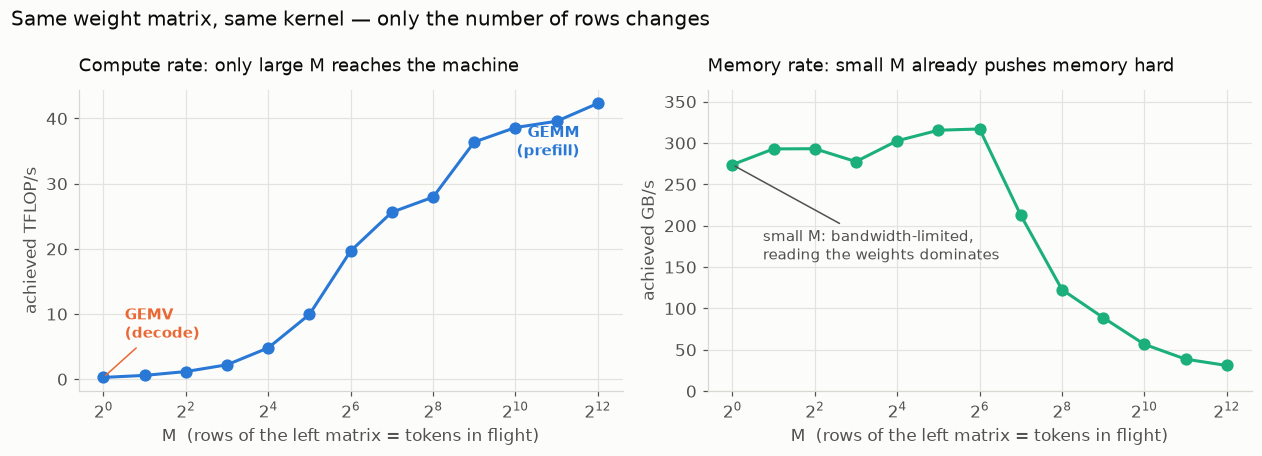

In [13]:
figure, (left, right) = plt.subplots(1, 2, figsize=(11.5, 4.2))

left.plot([r["m"] for r in sweep], [r["tflops"] for r in sweep], color=PREFILL_COLOR, marker="o")
left.set_xscale("log", base=2)
left.set_title("Compute rate: only large M reaches the machine")
left.set_xlabel("M  (rows of the left matrix = tokens in flight)"); left.set_ylabel("achieved TFLOP/s")
left.annotate("GEMV\n(decode)", (sweep[0]["m"], sweep[0]["tflops"]), textcoords="offset points",
              xytext=(14, 26), color=DECODE_COLOR, fontsize=10, fontweight="bold",
              arrowprops=dict(arrowstyle="-", color=DECODE_COLOR, lw=1))
left.annotate("GEMM\n(prefill)", (sweep[-1]["m"], sweep[-1]["tflops"]), textcoords="offset points",
              xytext=(-12, -34), ha="right", color=PREFILL_COLOR, fontsize=10, fontweight="bold")

right.plot([r["m"] for r in sweep], [r["gbps"] for r in sweep], color=ACCENT_COLOR, marker="o")
right.set_xscale("log", base=2)
right.set_title("Memory rate: small M already pushes memory hard")
right.set_xlabel("M  (rows of the left matrix = tokens in flight)"); right.set_ylabel("achieved GB/s")
right.set_ylim(0, max(r["gbps"] for r in sweep) * 1.15)
right.annotate("small M: bandwidth-limited,\nreading the weights dominates",
               (sweep[0]["m"], sweep[0]["gbps"]), textcoords="offset points", xytext=(20, -62),
               color=INK_SOFT, fontsize=10, arrowprops=dict(arrowstyle="-", color=INK_SOFT, lw=1))

figure.suptitle("Same weight matrix, same kernel — only the number of rows changes", x=0.005, ha="left", fontsize=13)
figure.tight_layout()
plt.show()

왼쪽 그래프가 이 장의 그림입니다. $M$이 작을 때 **연산 처리량은 바닥**입니다.
그런데 오른쪽을 보면 같은 구간에서 **메모리 처리량은 이미 꽤 높습니다.**
즉 $M=1$일 때 GPU는 놀고 있는 게 아니라 **메모리를 나르느라 바쁩니다**. 연산기만 놀 뿐이죠.

$M$을 키우면 어느 지점부터 연산 처리량이 평평해집니다. 그 지점이 memory-bound에서 compute-bound로 넘어가는 **전이점**입니다.
그 전에는 $M$을 키워도 시간이 거의 안 늘고(공짜 배칭), 그 후에는 $M$에 비례해 늘어납니다.

전이점이 정확히 어디인지는 하드웨어가 정합니다. 그것을 하나의 그림으로 만든 것이 roofline입니다.

## §7. Roofline Model

roofline은 위 두 그래프를 하나로 합칩니다. 가로축을 **arithmetic intensity**, 세로축을 **달성 연산 성능**으로 두면
하드웨어가 낼 수 있는 최대치는 단 두 개의 직선으로 그려집니다.

$$\text{성능}_{\max}(\text{AI}) \;=\; \min\big(\underbrace{\pi}_{\text{연산 천장}},\; \underbrace{\beta \times \text{AI}}_{\text{대역폭 경사}}\big)$$

두 선이 만나는 곳이 **ridge point**입니다.

$$\text{AI}_{\text{ridge}} = \frac{\pi}{\beta}$$

- AI < ridge → **memory-bound.** 연산을 줄여도 소용없습니다. 바이트를 줄이세요.
- AI > ridge → **compute-bound.** 대역폭을 늘려도 소용없습니다. 연산을 줄이거나 더 빠른 커널을 쓰세요.

$\pi$와 $\beta$는 스펙시트가 아니라 **이 기계에서 직접 재야** 합니다. 스펙시트 값은 실제로 도달할 수 없는 경우가 많습니다.

In [14]:
PEAK_TFLOPS = prof.measure_peak_flops(DEVICE, DTYPE, size=8192)
PEAK_GBPS = prof.measure_peak_bandwidth(DEVICE, DTYPE)
RIDGE = prof.ridge_point(PEAK_TFLOPS, PEAK_GBPS)

print(f"measured peak compute    : {PEAK_TFLOPS:8.1f} TFLOP/s  ({RUN.dtype}, 8192^3 GEMM)")
print(f"measured peak bandwidth  : {PEAK_GBPS:8.1f} GB/s     (large device-to-device copy)")
print(f"ridge point              : {RIDGE:8.1f} FLOP/byte")
print(f"\n이 GPU는 메모리에서 1바이트를 끌어오는 동안 약 {RIDGE:.0f}번의 부동소수점 연산을 할 수 있다.")
print("그만큼 재사용하지 못하는 커널은 전부 대역폭에 묶인다.")

measured peak compute    :     42.9 TFLOP/s  (float16, 8192^3 GEMM)
measured peak bandwidth  :    418.5 GB/s     (large device-to-device copy)
ridge point              :    102.5 FLOP/byte

이 GPU는 메모리에서 1바이트를 끌어오는 동안 약 102번의 부동소수점 연산을 할 수 있다.
그만큼 재사용하지 못하는 커널은 전부 대역폭에 묶인다.


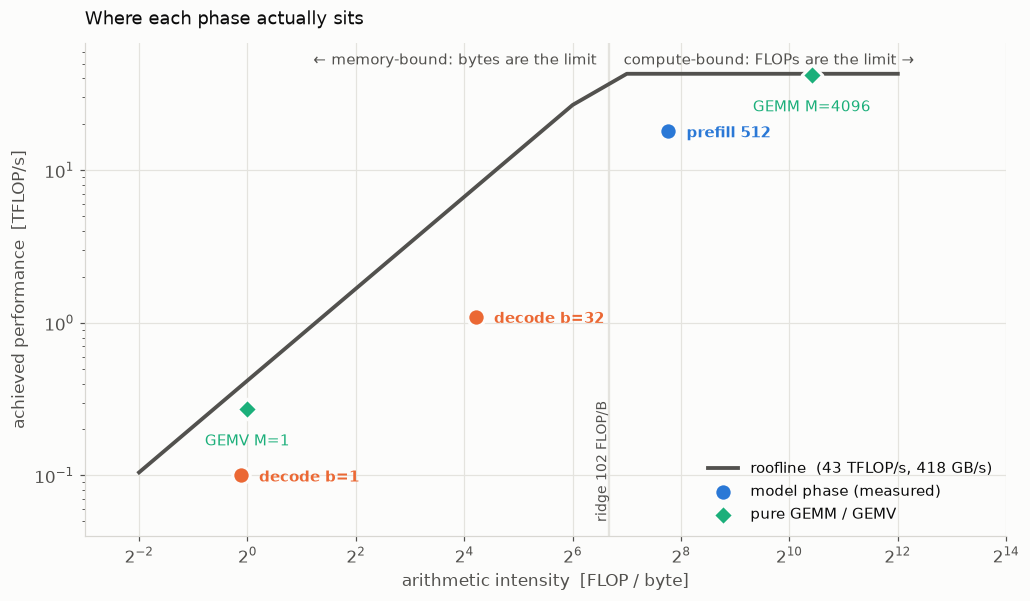

In [15]:
def model_point(label: str, *, batch: int, new_tokens: int, context_len: int, ms: float) -> dict:
    workload = prof.step_workload(CFG, batch=batch, new_tokens=new_tokens, context_len=context_len, dtype=DTYPE)
    return {"label": label, "ai": workload.arithmetic_intensity, "tflops": workload.flops / (ms / 1e3) / 1e12}


points = [
    model_point("prefill 512", batch=1, new_tokens=512, context_len=512, ms=prefill_timing.ms),
    model_point("decode b=1", batch=1, new_tokens=1, context_len=CONTEXT, ms=decode_graph.ms),
    model_point("decode b=32", batch=32, new_tokens=1, context_len=CONTEXT, ms=rows[-1]["ms"]),
]
micro = [
    {"label": "GEMV M=1", "ai": sweep[0]["ai"], "tflops": sweep[0]["tflops"]},
    {"label": "GEMM M=4096", "ai": sweep[-1]["ai"], "tflops": sweep[-1]["tflops"]},
]

figure, axes = plt.subplots(figsize=(9.5, 5.6))
grid = [2**e for e in range(-2, 13)]
axes.plot(grid, [prof.roofline_ceiling(x, PEAK_TFLOPS, PEAK_GBPS) for x in grid],
          color=INK_SOFT, lw=2.5, label=f"roofline  ({PEAK_TFLOPS:.0f} TFLOP/s, {PEAK_GBPS:.0f} GB/s)")
axes.axvline(RIDGE, color=GRID, lw=1.5, zorder=0)
axes.set_xscale("log", base=2); axes.set_yscale("log", base=10)
axes.set_xlabel("arithmetic intensity  [FLOP / byte]"); axes.set_ylabel("achieved performance  [TFLOP/s]")
axes.set_title("Where each phase actually sits")

for point, color in zip(points, (PREFILL_COLOR, DECODE_COLOR, DECODE_COLOR)):
    axes.scatter(point["ai"], point["tflops"], s=130, color=color, zorder=5,
                 edgecolor=SURFACE, linewidth=2,
                 label="model phase (measured)" if point is points[0] else None)
    axes.annotate(point["label"], (point["ai"], point["tflops"]), textcoords="offset points",
                  xytext=(12, -4), color=color, fontsize=10, fontweight="bold")
for point in micro:
    axes.scatter(point["ai"], point["tflops"], s=90, color=ACCENT_COLOR, marker="D", zorder=5,
                 edgecolor=SURFACE, linewidth=2,
                 label="pure GEMM / GEMV" if point is micro[0] else None)
    axes.annotate(point["label"], (point["ai"], point["tflops"]), textcoords="offset points",
                  xytext=(0, -24), ha="center", color=ACCENT_COLOR, fontsize=10)
axes.set_xlim(2**-3, 2**14)

top = PEAK_TFLOPS * 1.6
axes.set_ylim(min(p["tflops"] for p in points) * 0.4, top)
# 지붕 위 빈 띠에 영역 이름을 둔다 — 아래쪽은 측정점이 차지한다
axes.annotate("← memory-bound: bytes are the limit", (RIDGE * 0.85, top * 0.72), ha="right",
              color=INK_SOFT, fontsize=10)
axes.annotate("compute-bound: FLOPs are the limit →", (RIDGE * 1.2, top * 0.72), ha="left",
              color=INK_SOFT, fontsize=10)
axes.annotate(f"ridge {RIDGE:.0f} FLOP/B", (RIDGE, axes.get_ylim()[0] * 1.3), rotation=90,
              color=INK_SOFT, fontsize=9, ha="right")
axes.legend(frameon=False, loc="lower right", fontsize=10)
figure.tight_layout()
plt.show()

이 한 장에 1장 전체가 들어 있습니다.

- **prefill은 ridge point의 오른쪽**에 있습니다. compute-bound입니다. 더 빠르게 하려면 연산을 줄이거나(sparse, 더 나은 커널)
  텐서코어를 더 잘 써야 합니다. 대역폭을 늘려봐야 소용없습니다.
- **decode는 ridge point의 한참 왼쪽**, 대역폭 경사선 위에 붙어 있습니다. memory-bound입니다.
  더 빠르게 하려면 읽을 바이트를 줄이거나(양자화, KV 캐시 압축) 배칭으로 AI를 오른쪽으로 밀어야 합니다.
- batch를 32로 키운 decode 점이 **오른쪽 위로 이동**한 것을 보세요. 배칭이 하는 일이 정확히 이것입니다.
- GEMV와 GEMM 마이크로벤치 점이 두 phase와 같은 자리에 찍힙니다. §4의 주장 — decode는 GEMV, prefill은 GEMM — 의 증거입니다.

**천장과 점 사이의 거리는 구현이 남긴 숙제입니다.** prefill 점이 연산 천장에 한참 못 미친다면,
그건 하드웨어가 아니라 이 baseline 구현(비융합 norm, 매 호출 RoPE 재계산, 마스크 생성)의 문제입니다.
2장 이후에서 그 간격을 메우는 게 우리 일입니다.

## §8. batch size · sequence length · hidden dimension

세 손잡이가 roofline 위의 점을 각각 어디로 옮기는지 봅니다. 이것이 성능 직관의 실전 버전입니다.

In [16]:
# (1) batch: decode의 AI를 오른쪽으로 민다
batch_ai = [(r["batch"], r["ai"], r["tok_s"]) for r in rows]

# (2) context length: KV 읽기가 선형으로 늘어 decode를 더 memory-bound로 만든다
CONTEXTS = [128, 256, 512, 1024]
context_rows = []
for context_len in CONTEXTS:
    timing = time_decode(1, context_len, use_graph=True)
    moved = prof.transformer_bytes(CFG, batch=1, new_tokens=1, context_len=context_len, dtype=DTYPE)
    context_rows.append({
        "ctx": context_len, "ms": timing.ms,
        "kv_share": (moved["kv_read"] + moved["kv_write"]) / moved["total"],
    })

# (3) hidden dimension: GEMM이 커지며 prefill을 compute-bound 쪽으로 민다
HIDDENS = [256, 512, 1024, 2048]
hidden_rows = []
for hidden in HIDDENS:
    small = ModelConfig(vocab_size=8192, hidden_size=hidden, n_layers=4, n_heads=8, n_kv_heads=2,
                        intermediate_size=hidden * 11 // 4, max_seq_len=512)
    small_run = RunConfig(batch_size=1, prompt_len=256, decode_len=1, device=RUN.device, dtype=RUN.dtype)
    small_model, _, _, small_prompt, _ = prepare(small, small_run)
    with torch.inference_mode():
        small_cache = small_model.new_cache(1, DEVICE, DTYPE)

        def step() -> None:
            small_cache.reset()
            small_model.forward_prefill(small_prompt, small_cache)

        timing = prof.timeit(prof.capture_graph(step, device=DEVICE), device=DEVICE, warmup=3, iters=10)
    flops = prof.transformer_flops(small, batch=1, new_tokens=256, context_len=256)["total"]
    workload = prof.step_workload(small, batch=1, new_tokens=256, context_len=256, dtype=DTYPE)
    hidden_rows.append({"hidden": hidden, "tflops": timing.tflops(flops), "ai": workload.arithmetic_intensity})
    del small_model, small_cache, small_prompt
    release()

print(f"{'batch':>6} {'decode AI':>11} | {'context':>8} {'ms/step':>9} {'KV share':>9} | {'hidden':>7} {'prefill TFLOP/s':>16}")
for i in range(4):
    b = batch_ai[i]; c = context_rows[i]; h = hidden_rows[i]
    print(f"{b[0]:>6} {b[1]:>11.1f} | {c['ctx']:>8} {c['ms']:>8.2f} {c['kv_share']:>8.0%} | {h['hidden']:>7} {h['tflops']:>16.2f}")

# 이 카드에 올릴 수 있는 문맥은 짧다. 긴 문맥에서 KV가 어디까지 가는지는 계산으로 확인한다.
print("\n긴 문맥에서 KV가 차지하는 비중 (analytic, 측정 아님)")
print(f"{'context':>9} {'batch 1':>9} {'batch 32':>9}")
for context_len in (1024, 4096, 16384, 65536):
    shares = []
    for batch in (1, 32):
        moved = prof.transformer_bytes(CFG, batch=batch, new_tokens=1, context_len=context_len, dtype=DTYPE)
        shares.append((moved["kv_read"] + moved["kv_write"]) / moved["total"])
    print(f"{context_len:>9} {shares[0]:>8.0%} {shares[1]:>8.0%}")

 batch   decode AI |  context   ms/step  KV share |  hidden  prefill TFLOP/s
     1         0.9 |      128     3.94       0% |     256             2.65
     2         1.8 |      256     4.14       1% |     512             6.56
     4         3.5 |      512     4.51       2% |    1024            14.47
     8         6.5 |     1024     5.86       3% |    2048            11.94

긴 문맥에서 KV가 차지하는 비중 (analytic, 측정 아님)
  context   batch 1  batch 32
     1024       3%      51%
     4096      12%      80%
    16384      35%      94%
    65536      69%      98%


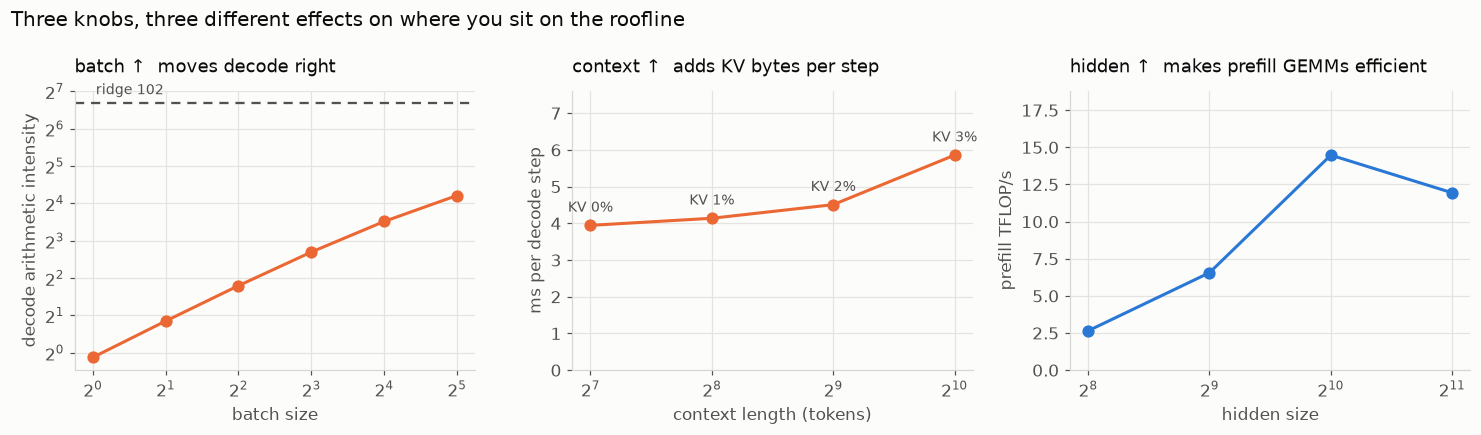

In [17]:
figure, (one, two, three) = plt.subplots(1, 3, figsize=(13.5, 4.0))

one.plot([b[0] for b in batch_ai], [b[1] for b in batch_ai], color=DECODE_COLOR, marker="o")
one.axhline(RIDGE, color=INK_SOFT, lw=1.5, ls=(0, (4, 3)))
one.annotate(f"ridge {RIDGE:.0f}", (batch_ai[0][0], RIDGE), textcoords="offset points",
             xytext=(2, 6), color=INK_SOFT, fontsize=9)
one.set_xscale("log", base=2); one.set_yscale("log", base=2)
one.set_title("batch ↑  moves decode right")
one.set_xlabel("batch size"); one.set_ylabel("decode arithmetic intensity")

two.plot([c["ctx"] for c in context_rows], [c["ms"] for c in context_rows], color=DECODE_COLOR, marker="o")
two.set_xscale("log", base=2)
two.set_title("context ↑  adds KV bytes per step")
two.set_xlabel("context length (tokens)"); two.set_ylabel("ms per decode step")
two.set_ylim(0, max(c["ms"] for c in context_rows) * 1.3)
for c in context_rows:
    two.annotate(f"KV {c['kv_share']:.0%}", (c["ctx"], c["ms"]), textcoords="offset points",
                 xytext=(0, 9), ha="center", color=INK_SOFT, fontsize=9)

three.plot([h["hidden"] for h in hidden_rows], [h["tflops"] for h in hidden_rows], color=PREFILL_COLOR, marker="o")
three.set_xscale("log", base=2)
three.set_title("hidden ↑  makes prefill GEMMs efficient")
three.set_xlabel("hidden size"); three.set_ylabel("prefill TFLOP/s")
three.set_ylim(0, max(h["tflops"] for h in hidden_rows) * 1.3)

figure.suptitle("Three knobs, three different effects on where you sit on the roofline", x=0.005, ha="left", fontsize=13)
figure.tight_layout()
plt.show()

**batch size.** decode의 AI를 거의 선형으로 끌어올립니다 ($\text{AI} \approx B$).
ridge point 점선에 닿기 전까지는 배칭이 거의 공짜입니다. 그 선을 넘으면 decode도 compute-bound가 되고,
그때부터는 batch를 키우면 지연이 정직하게 늘어납니다. **연속 배칭(continuous batching)이 서빙의 1순위 기법인 이유**입니다.

**sequence length.** 문맥이 길어지면 스텝마다 읽어야 할 KV 캐시가 선형으로 늘어납니다.
가중치 바이트는 고정이므로 처음엔 티가 안 나다가, 문맥이 길어질수록 KV가 전체 바이트를 잠식하고 결국 지배합니다.
위 표의 계산값을 보면 문맥이 수만 토큰에 이를 때 KV가 바이트의 대부분을 먹습니다 —
이 카드에 올릴 수 있는 문맥이 짧아 측정으로는 3%까지밖에 못 봤을 뿐입니다.
KV 캐시가 긴 문맥 서빙의 주적이고, GQA·MQA·KV 압축·PagedAttention이 전부 이 항을 겨냥합니다.
(prefill 쪽에서는 attention FLOPs가 $O(T^2)$로 자란다는 별개의 문제도 생깁니다.)

**hidden dimension.** 차원이 커질수록 GEMM이 커지고 텐서코어 효율이 올라가다가, GPU를 다 채우고 나면 평평해집니다.
작은 모델이 "GPU를 못 채운다"는 말이 이 뜻입니다 — 큰 모델이 절대 시간은 더 걸려도 **하드웨어는 더 잘 씁니다.**
(여기에는 §1의 효과도 겹칩니다. 작은 모델일수록 커널 하나가 짧아 런치 비용의 비중이 커집니다.
CUDA graph로 재서 그 영향을 줄였지만 완전히 없앤 것은 아닙니다.)

## §9. 정리

### 판별 절차

새 워크로드를 만나면 이 순서로 봅니다.

1. **FLOPs와 Bytes를 센다** → AI를 구한다. (측정이 아니라 계산입니다. 코드를 돌리기 전에 할 수 있습니다.)
2. **이 기계의 ridge point를 잰다** → $\pi / \beta$.
3. **비교한다.** AI < ridge면 memory-bound, 크면 compute-bound.
4. **실측을 roofline 위에 얹는다.** 천장까지의 거리가 구현이 남긴 숙제입니다.
5. **병목에 맞는 처방만 쓴다.** memory-bound에 커널 융합을 하거나 compute-bound에 양자화를 하면 헛수고입니다.

### 이 장의 결론

| | Prefill | Decode |
|---|---|---|
| 연산 모양 | GEMM (행렬×행렬) | GEMV (벡터×행렬) |
| 병목 | 연산 (compute-bound) | 메모리 대역폭 (memory-bound) |
| 사용자 지표 | TTFT | TPOT |
| 길이에 따라 | 토큰 수에 비례, attention은 $O(T^2)$ | 문맥 길이에 따라 KV 읽기 증가 |
| 배칭 효과 | 이미 포화, 이득 적음 | 거의 공짜, 이득 큼 |
| 처방 | 더 나은 커널, chunked prefill, 프롬프트 캐싱 | 양자화, KV 압축, 연속 배칭, CUDA graph |

**한 줄 요약:** prefill은 연산을 사고, decode는 대역폭을 삽니다.

### 연습문제

1. **양자화의 상한을 예측하라.** 가중치를 fp16에서 int8로 바꾸면 `transformer_bytes`의 어느 항이 줄고,
   batch 1 decode의 TPOT은 최대 몇 배 빨라지는가? 실제로는 왜 그보다 덜 나올까?
   *(힌트: KV 캐시와 활성값은 그대로일 수 있다. `dtype=torch.int8`로 `step_workload`를 다시 계산해 AI 변화를 보라.)*

2. **손익분기 batch를 구하라.** 이 GPU에서 decode가 memory-bound를 벗어나는 batch size는 얼마인가?
   §8의 첫 그래프에서 읽은 값과, §2의 처리량 곡선이 꺾이기 시작하는 지점이 일치하는가?
   일치하지 않는다면 무엇이 그보다 먼저 한계가 되었는가?

3. **어느 쪽 문제인지 판정하라.** 프롬프트 2000 토큰, 생성 100 토큰인 서비스에서 사용자가 "응답이 느리다"고 한다.
   §3의 계측 방식으로 TTFT와 TPOT을 따로 재고, 전체 지연에서 각각이 차지하는 비중을 구하라.
   prefill을 2배 빠르게 하는 것과 decode를 2배 빠르게 하는 것 중 어느 쪽이 더 이득인가?

### 다음 장 예고

1장에서 decode의 두 하한을 봤습니다 — 가중치 바이트와 KV 캐시 바이트.
2장은 그중 뒤엣것, **KV 캐시**를 정면으로 다룹니다. 메모리에서 실제로 어떻게 배치되는지,
왜 단순 사전할당이 서빙에서 낭비가 되는지, 그리고 PagedAttention과 연속 배칭이 무엇을 고치는지.
이 저장소의 `KVCache`가 바로 그 실험 대상입니다.